In [23]:
from sklearn.datasets import make_regression
import numpy as np

In [24]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)     

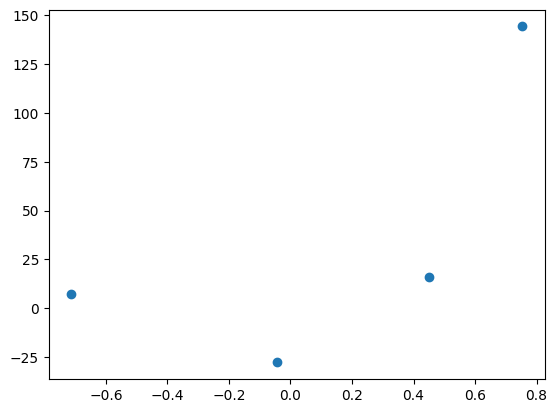

In [25]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

<h1>Applying OLS</h1>

In [26]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
reg.coef_

array([78.35063668])

In [28]:
reg.intercept_

np.float64(26.15963284313262)

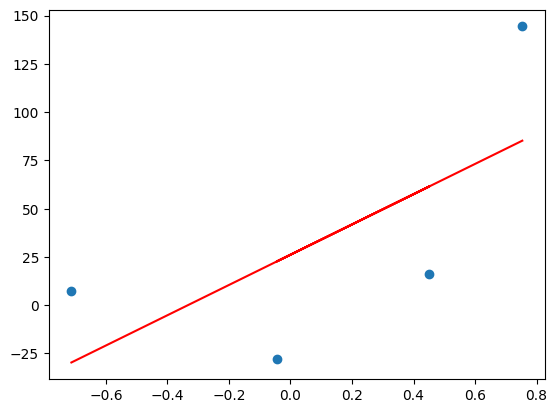

In [29]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

<P>Now the idea is to reach the same intercept using gradient descent and assuming slope is constant taking m=78.35.</P>

<h1>Applying Gradient Descent
</h1>

<p><b>assuming slope is constant m = 78.35, and let's assume the starting value for intercept b = 0</b></p>

In [30]:
y_pred=((78.35*X)+0).reshape(4)

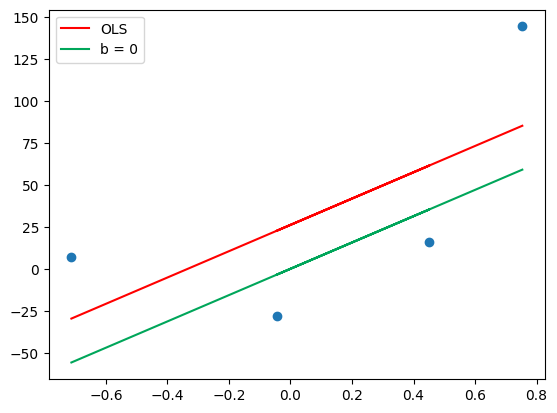

In [31]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [32]:
m=78.35
b=0

In [33]:
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [34]:
#taking learning rate as 0.1
lr=0.1

In [35]:
step_size=loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [36]:
#calculating the new intercept
b=b-step_size
b

np.float64(20.927763408209216)

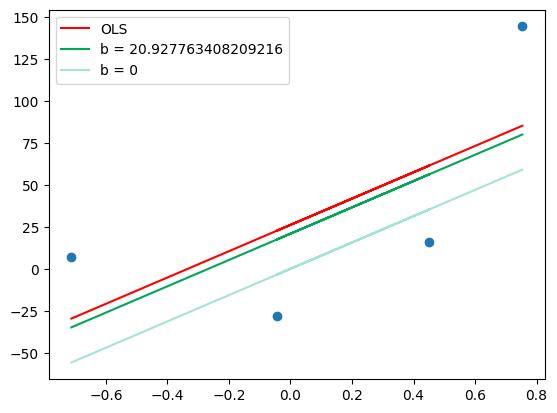

In [37]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [38]:
#Iteration 2
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [39]:
step_size=lr*loss_slope
step_size

np.float64(-4.185552681641844)

In [40]:
b=b-step_size
b

np.float64(25.11331608985106)

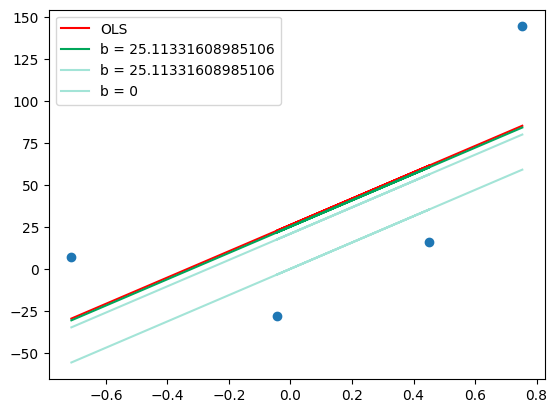

In [41]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [42]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

step_size = loss_slope*lr

b = b - step_size
b

np.float64(25.95042662617943)

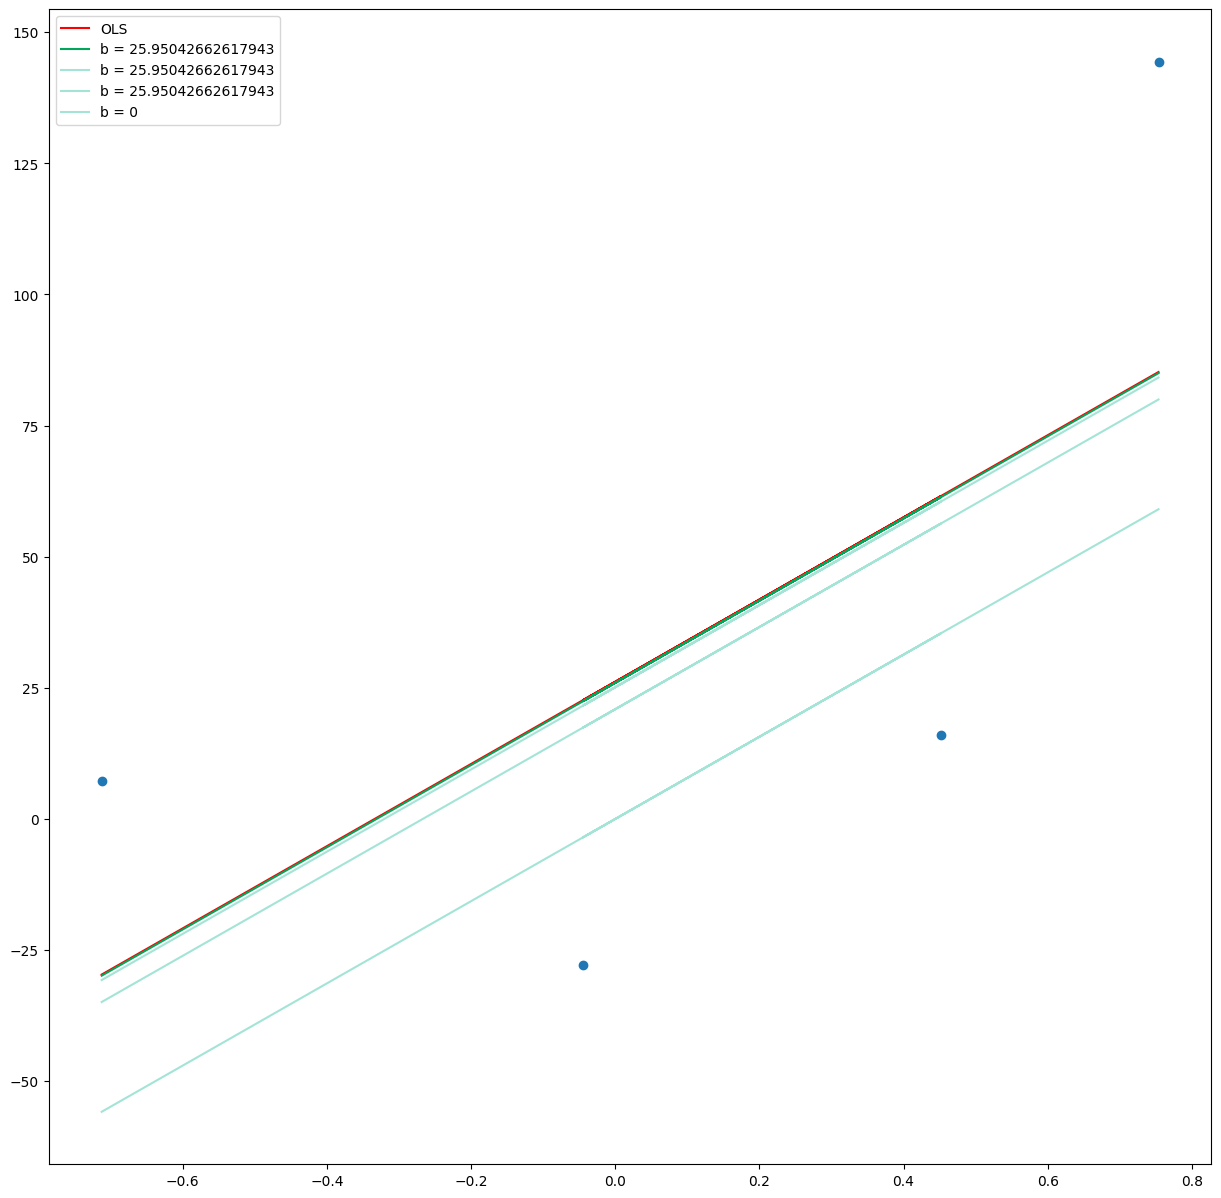

In [43]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

<p>In the Gradient Descent part, we started with the slope fixed at 78.35 and the intercept (b=0), which produced a regression line with a large error; we then calculated the slope of the loss with respect to (b), used a learning rate of 0.1 to determine the step size, and updated (b) in the opposite direction of the gradient. After the first update, (b) moved from 0 to about 20.93, and further iterations moved it closer to the optimal OLS intercept of about 26.16, showing that Gradient Descent gradually converges toward the parameter value that minimizes the loss. 
</p>

<h1>Applying Using Loop</h1>

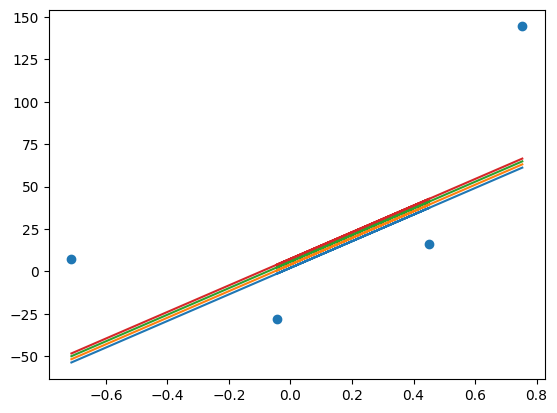

In [46]:
b=0
m=78.35
lr=0.01
epochs=4

for i in range(epochs):
    loss_slope=-2*np.sum(y-m*X.ravel()-b)
    b=b-(lr*loss_slope)

    y_pred=m*X+b
    plt.plot(X,y_pred)

plt.scatter(X,y)